# **Consolidação de Medalhas Olímpicas**

Dados históricos (1896–2022):
Base dos Dados – Histórico das Olimpíadas
https://basedosdados.org/dataset/62f8cb83-ac37-48be-874b-b94dd92d3e2b

Dados Paris 2024:
Kaggle – Paris 2024 Olympic Summer Games
https://www.kaggle.com/datasets/piterfm/paris-2024-olympic-summer-games/data

### **1. Instalar e importar bibliotecas**

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', None)

plt.style.use('ggplot')

### **2. Carregar os datasets**

In [29]:
# carregar dados históricos
historico = pd.read_csv("game_medal_tally.csv")

# carregar dados Paris 2024
paris2024 = pd.read_csv("medals_total.csv")

### **3. Visualizar os dados**

In [30]:
print("Histórico:")
display(historico.head())

print("Paris 2024:")
display(paris2024.head())

Histórico:


,year,edition,edition_id,country,country_noc,gold,silver,bronze,total
0,1896,1896 Summer Olympics,1,Greece,GRE,10,18,19,47
1,1900,1900 Summer Olympics,2,France,FRA,31,41,40,112
2,1900,1900 Summer Olympics,2,United States,USA,20,13,15,48
3,1904,1904 Summer Olympics,3,United States,USA,80,85,83,248
4,1908,1908 Summer Olympics,5,Great Britain,GBR,56,51,39,146


Paris 2024:


,country_code,country,country_long,Gold Medal,Silver Medal,Bronze Medal,Total
0,USA,United States,United States of America,40,44,42,126
1,CHN,China,People's Republic of China,40,27,24,91
2,JPN,Japan,Japan,20,12,13,45
3,AUS,Australia,Australia,18,19,16,53
4,FRA,France,France,16,26,22,64


### **4. Padronizar colunas dos datasets**

Os dois arquivos possuem nomes de colunas diferentes

In [31]:
# renomear colunas de Paris 2024
paris2024 = paris2024.rename(columns={
    'country_code':'country_noc',
    'country':'country',
    'Gold Medal':'gold',
    'Silver Medal':'silver',
    'Bronze Medal':'bronze',
    'Total':'total'
})

# adicionar colunas que não existem
paris2024['year'] = 2024
paris2024['edition'] = "2024 Summer Olympics"

# reorganizar colunas
paris2024 = paris2024[['year','edition','country','country_noc','gold','silver','bronze','total']]

### **5. Identificar Jogos de Verão e Inverno**

In [32]:
def identificar_tipo(edition):
    if "Winter" in edition:
        return "Winter"
    else:
        return "Summer"

historico["season"] = historico["edition"].apply(identificar_tipo)
paris2024["season"] = "Summer"

### **6. Unir os datasets**

In [33]:
dados = pd.concat([historico, paris2024], ignore_index=True)

### **7. Tratamento de valores nulos**

In [34]:
# verificar valores nulos
print(dados.isnull().sum())

# substituir valores nulos por 0 nas medalhas
dados[['gold','silver','bronze','total']] = dados[['gold','silver','bronze','total']].fillna(0)

year            0
edition         0
edition_id     92
country         0
country_noc     0
gold            0
silver          0
bronze          0
total           0
season          0
dtype: int64


### **8. Consolidação de medalhas**

🥇 Jogos de Verão

In [35]:
verao = dados[dados['season']=="Summer"]

medalhas_verao = verao.groupby('country_noc')[['gold','silver','bronze','total']].sum()

medalhas_verao = medalhas_verao.sort_values('total', ascending=False)

display(medalhas_verao)

,gold,silver,bronze,total
country_noc,,,,
USA,1122,891,792,2805
GBR,314,356,349,1019
URS,395,319,296,1010
FRA,262,292,323,877
GER,255,286,304,845
CHN,303,226,198,727
ITA,241,214,233,688
AUS,180,189,228,597
HUN,190,168,186,544


**❄️ Jogos de Inverno**

In [36]:
inverno = dados[dados['season']=="Winter"]

medalhas_inverno = inverno.groupby('country_noc')[['gold','silver','bronze','total']].sum()

medalhas_inverno = medalhas_inverno.sort_values('total', ascending=False)

display(medalhas_inverno)

,gold,silver,bronze,total
country_noc,,,,
NOR,148,134,123,405
USA,113,122,95,330
GER,112,104,70,286
AUT,71,88,91,250
CAN,77,72,76,225
URS,78,57,59,194
SWE,65,51,60,176
FIN,45,65,65,175
SUI,63,47,58,168


**🌍 Total Geral**

In [37]:
medalhas_total = dados.groupby('country_noc')[['gold','silver','bronze','total']].sum()

medalhas_total = medalhas_total.sort_values('total', ascending=False)

display(medalhas_total)

,gold,silver,bronze,total
country_noc,,,,
USA,1235,1013,887,3135
URS,473,376,355,1204
GER,367,390,374,1131
GBR,326,361,366,1053
FRA,303,334,378,1015
ITA,283,257,289,829
CHN,325,258,221,804
SWE,220,237,251,708
JPN,206,190,224,620


### **9. Gráfico**

**📊 Top 50 Jogos de Verão**

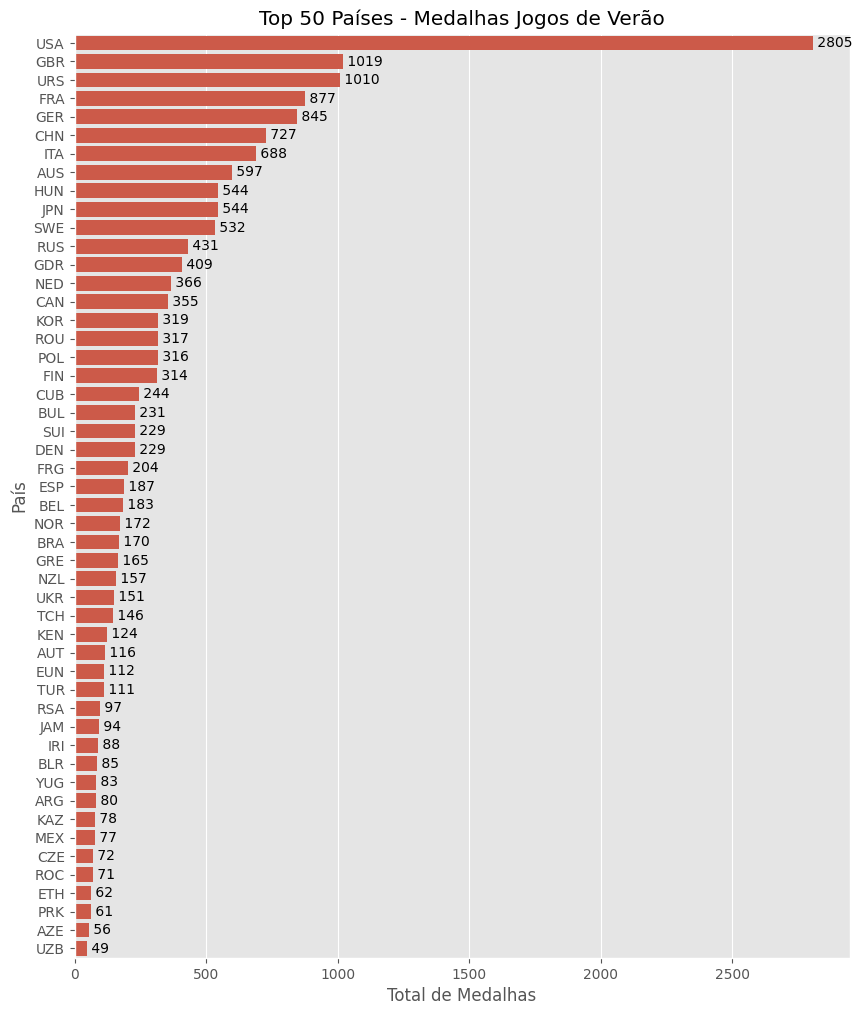

In [38]:
top50_verao = medalhas_verao.head(50)

plt.figure(figsize=(10,12))
sns.barplot(x=top50_verao['total'], y=top50_verao.index)

for i, v in enumerate(top50_verao['total']):
    plt.text(v, i, f' {v}', va='center')

plt.title("Top 50 Países - Medalhas Jogos de Verão")
plt.xlabel("Total de Medalhas")
plt.ylabel("País")

plt.show()

**📊 Top 50 Jogos de Inverno**

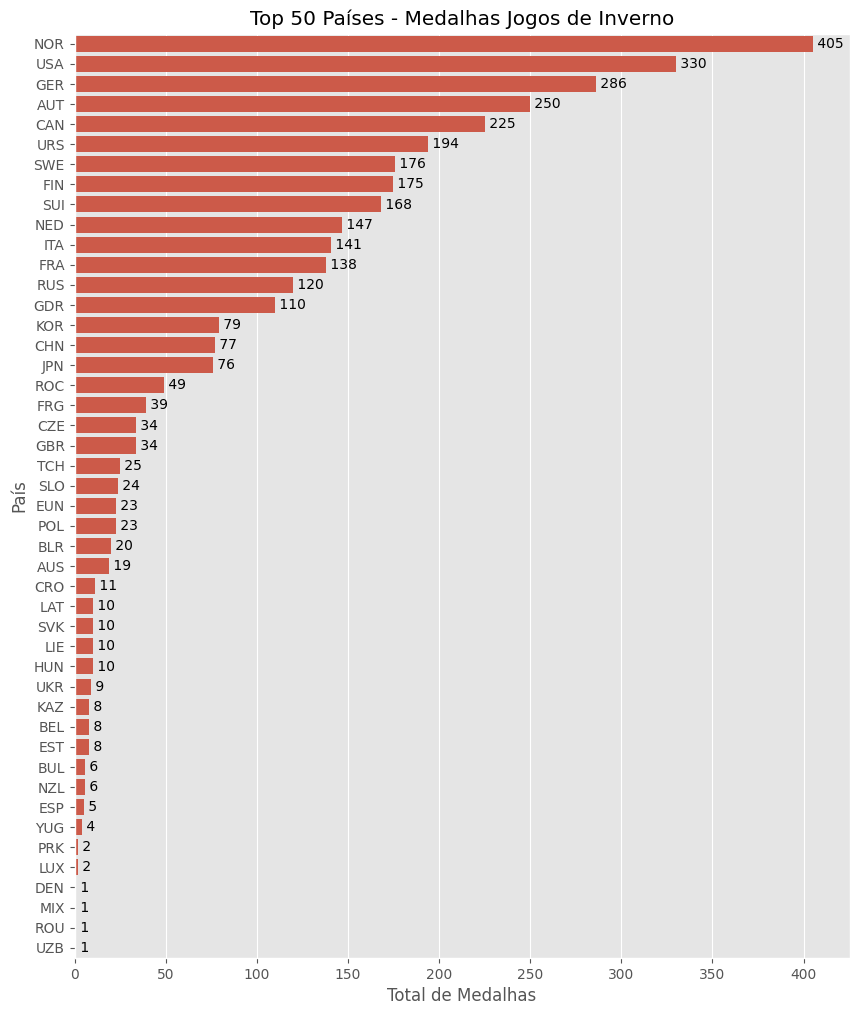

In [39]:
top50_inverno = medalhas_inverno.head(50)

plt.figure(figsize=(10,12))
sns.barplot(x=top50_inverno['total'], y=top50_inverno.index)

for i, v in enumerate(top50_inverno['total']):
    plt.text(v, i, f' {v}', va='center')

plt.title("Top 50 Países - Medalhas Jogos de Inverno")
plt.xlabel("Total de Medalhas")
plt.ylabel("País")

plt.show()

**📊 Top 50 Total Geral**

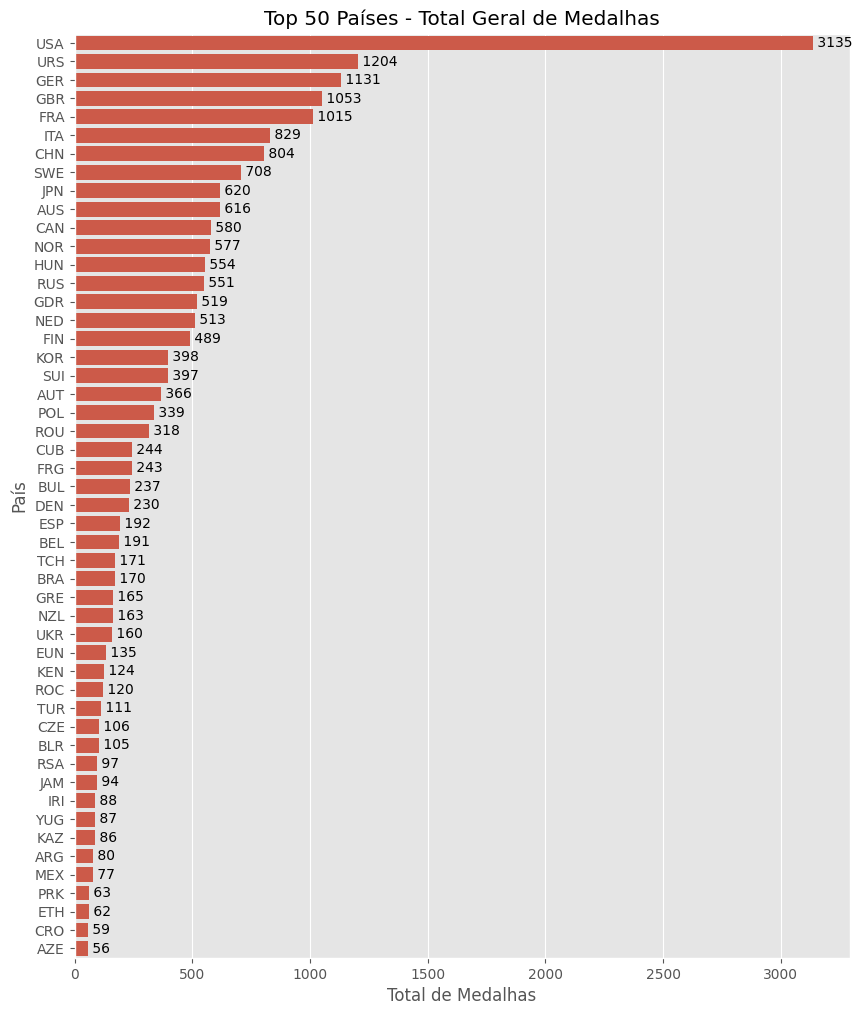

In [40]:
top50_total = medalhas_total.head(50)

plt.figure(figsize=(10,12))
sns.barplot(x=top50_total['total'], y=top50_total.index)

for i, v in enumerate(top50_total['total']):
    plt.text(v, i, f' {v}', va='center')

plt.title("Top 50 Países - Total Geral de Medalhas")
plt.xlabel("Total de Medalhas")
plt.ylabel("País")

plt.show()